In [277]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pytrends.request import TrendReq

# setup pytrend library and keyword define

In [278]:
pytrends = TrendReq(hl = 'en-=US' , tz = 360)
keyword = "Cloud Computing"

Data Request

In [279]:
pytrends.build_payload([keyword],cat = 0,timeframe = 'today 12-m',geo = '', gprop = '')

TooManyRequestsError: The request failed: Google returned a response with code 429

# Country wise Interest

C:\Users\GiBi\AppData\Local\Temp\ipykernel_1336\1467982809.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = region_data [keyword],y = region_data.index,palette = "Blues_d")


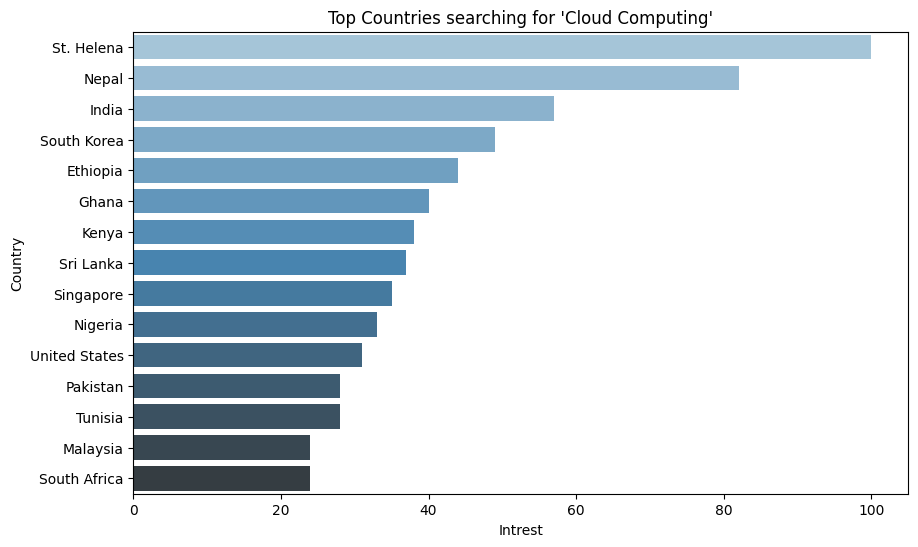

In [ ]:
region_data = pytrends.interest_by_region()
region_data = region_data.sort_values(by = keyword,ascending = False).head(15)
plt.figure(figsize = (10,6))
sns.barplot(x = region_data [keyword],y = region_data.index,palette = "Blues_d")
plt.title(f"Top Countries searching for '{keyword}'")
plt.xlabel("Intrest")
plt.ylabel("Country")
plt.show()

# World Map

In [ ]:
region_data = region_data.reset_index()  # moves geoName from index → column

fig = px.choropleth(
    region_data,
    locations="geoName",
    locationmode="country names",
    color=keyword,
    hover_name="geoName",
    color_continuous_scale="Blues",
    title=f"Search Interest for '{keyword}' by Country"
)
fig.show()

C:\Users\GiBi\AppData\Local\Temp\ipykernel_1336\1044783362.py:3: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


# Time wise Interest

In [ ]:
time_df = pytrends.interest_over_time()

c:\Users\GiBi\AppData\Local\Programs\Python\Python310\lib\site-packages\pytrends\request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


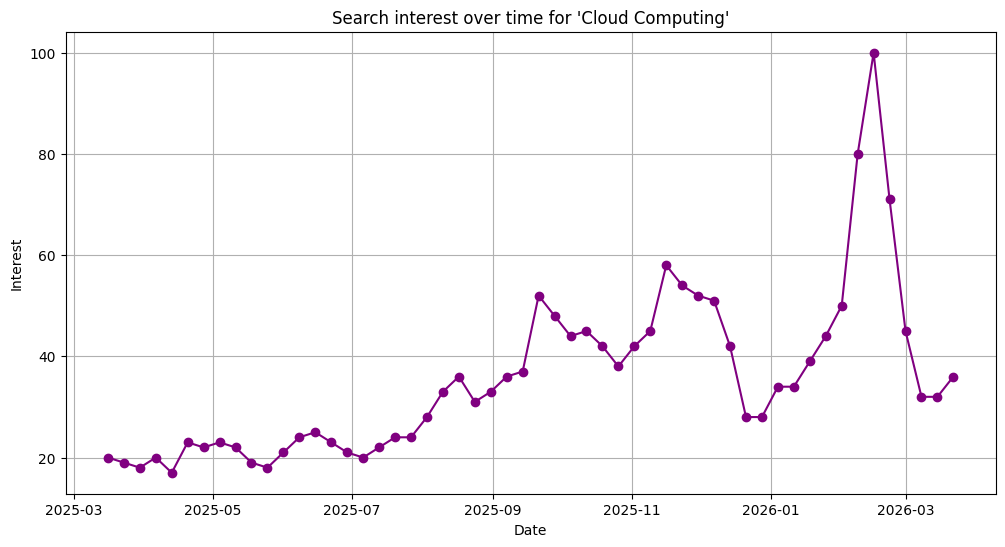

In [ ]:
plt.figure(figsize = (12,6))
plt.plot(time_df.index, time_df[keyword], marker = "o", color = "purple")
plt.title(f"Search interest over time for '{keyword}'")
plt.xlabel("Date")
plt.ylabel("Interest")
plt.grid(True)
plt.show()

# Comparing Multiple Keywords

In [ ]:
kw_list = ["cloud computing", "data science" , "Machine Learning"]
pytrends.build_payload(kw_list, cat = 0 , timeframe = 'today 12-m', geo = "" , gprop = "")

c:\Users\GiBi\AppData\Local\Programs\Python\Python310\lib\site-packages\pytrends\request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


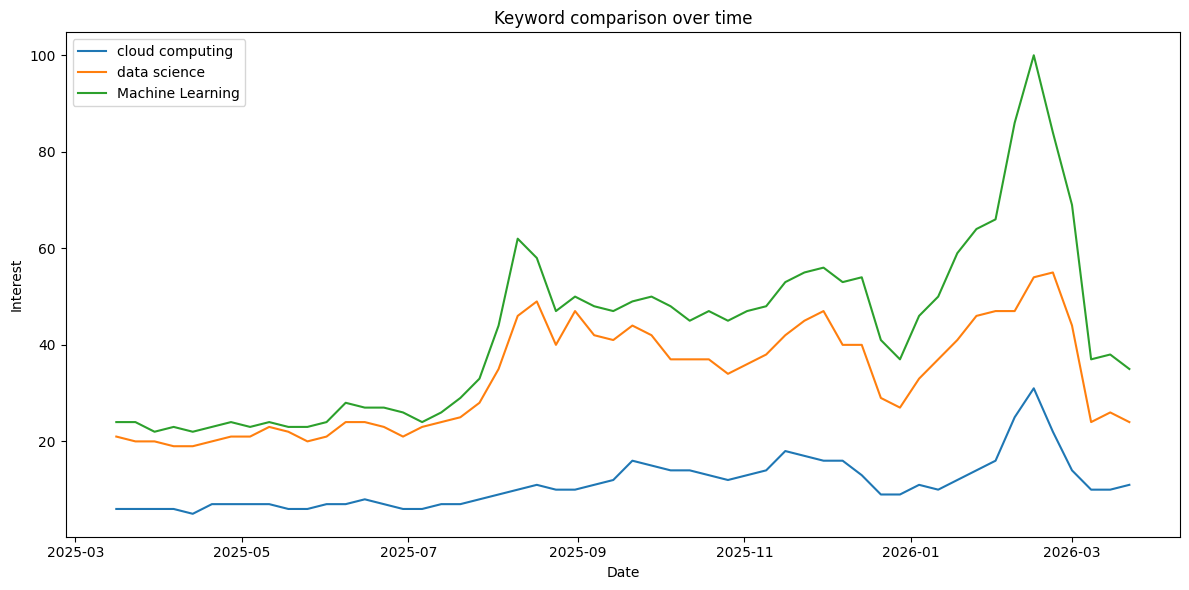

In [ ]:
compare_df = pytrends.interest_over_time()  # ✅ fixed
plt.figure(figsize=(12, 6))
for kw in kw_list:
    plt.plot(compare_df.index, compare_df[kw], label=kw)

plt.title("Keyword comparison over time")
plt.xlabel("Date")
plt.ylabel("Interest")
plt.legend()
plt.tight_layout()
plt.show()